# Video Segmentation: Cutting Long Videos into Training Clips

## LiveCC (Reference: CVPR 2025)

LiveCC uses **ASR-based segmentation** strategy. The core idea is:
> Split videos at natural speech pauses (silence gaps) while respecting sentence boundaries.

### LiveCC Segmentation Rules

From `livecc/data/production/sft_to_clips.py`:

| Rule | Pre-training | SFT |
|------|-------------|-----|
| Min clip length | 30s | 30s |
| Max clip length | 240s (60s for ablation) | 240s |
| Silence threshold | 3s between words | 3s between words |
| Sentence boundary | Not required (can split mid-sentence) | **Required** (must end with `.?!`, next starts uppercase) |
| Speech rate filter | 1-4 words/sec | N/A |

## Our Enhanced Approach: Visual + ASR Fusion Segmentation

We extend LiveCC's method with **visual scene change detection** to handle ultrasound teaching videos, where content transitions (US screen → PPT → talking head) are strong segmentation signals.

### Our Segmentation Rules

| Rule | Value | Rationale |
|------|-------|-----------|
| Min clip length | 30s | Same as LiveCC; too short = insufficient context |
| Max clip length | 300s | Slightly longer than LiveCC; ultrasound explanations tend to be longer |
| **Primary cut signal** | **Visual scene change** (histogram similarity < 0.3) | Ultrasound videos have distinct visual transitions between content types |
| **Cut alignment** | Nearest sentence boundary within ±10s of scene change | Ensures clips end with complete sentences |
| Fallback cut | At max_clip, find nearest sentence end (`.?!`) | For segments without visual changes |
| Sentence boundary | Required (end with `.?!`) | Same as LiveCC SFT; ensures coherent clip boundaries |

### Multi-Signal Cut Priority

```
Priority 1 (Best):  Visual scene change + Sentence boundary within ±10s
Priority 2 (Good):  ASR silence > 3s + Sentence boundary  
Priority 3 (OK):    Duration > max_clip → nearest sentence end
Priority 4 (Last):  Duration > max_clip + 60s → hard cut
```

### Algorithm

```python
# Input: ASR segments + video file
# Step 1: Compute visual similarity at each ASR segment midpoint
# Step 2: Identify scene_change points (similarity < threshold)
# Step 3: For each scene_change, find nearest sentence-ending segment (±10s)
# Step 4: Build clips between these natural cut points
# Step 5: Post-process: split any clip > max_clip at sentence boundaries
```

### Key Differences from LiveCC

| Aspect | LiveCC | Ours |
|--------|--------|------|
| Primary signal | ASR silence (>3s gap) | **Visual scene change** |
| Visual analysis | None | Grayscale histogram comparison per segment |
| Content awareness | None | Detects US→PPT→talking head transitions |
| Sentence alignment | Word-level (`.?!` + uppercase) | Segment-level (`.?!` ending) |
| ASR granularity | Word-level timestamps | Segment-level (faster-whisper) |
| Tolerance window | Exact gap position | ±10s around scene change |

In [1]:
import sys, os
os.chdir('..')
sys.path.append('scripts')

import json
import numpy as np
from pathlib import Path

## 1. Load ASR Transcript

In [2]:
# Load ASR result (from asr_pipeline)
transcript_path = "transcripts/8V649L5Q368.json"
if Path(transcript_path).exists():
    with open(transcript_path) as f:
        asr_data = json.load(f)
    segments = asr_data['segments']
    print(f"Video: {asr_data['video_id']}")
    print(f"Duration: {asr_data['duration_sec']:.1f}s ({asr_data['duration_sec']/60:.1f}min)")
    print(f"Segments: {len(segments)}")
    print(f"Language: {asr_data['language']}")
    print(f"\nFirst 5 segments:")
    for s in segments[:5]:
        print(f"  [{s['start']:6.1f} - {s['end']:6.1f}] {s['text'][:60]}")
else:
    print(f"Transcript not found: {transcript_path}")
    print("Run ASR pipeline first: python scripts/asr_pipeline.py")

Video: 8V649L5Q368
Duration: 1136.8s (18.9min)
Segments: 223
Language: en

First 5 segments:
  [   0.7 -    4.5] Hi, I'm Dr. John Kugler with the Stanford 25 Ultra Sound ser
  [   4.5 -    7.1] Today, we're going to be learning about lung ultrasound.
  [   7.1 -   12.0] Now, lung ultrasound is really important, especially in my p
  [  12.0 -   16.0] I use lung ultrasound all the time to evaluate patients for 
  [  16.2 -   22.3] Today, I want to focus on pneumothorax, pleural effusions, a


## 2. LiveCC-Style Segmentation Implementation

In [3]:
def segment_livecc_style(segments, min_clip_sec=30, max_clip_sec=240, silence_threshold=3.0):
    """
    LiveCC-style video segmentation based on ASR timestamps.
    
    Rules (from livecc/data/production/sft_to_clips.py):
    1. Clip must start at sentence boundary (prev ends with .?!, current starts uppercase)
    2. Clip ends when: silence > 3s OR duration > max_clip_sec
    3. Clip must be >= min_clip_sec to be kept
    
    Args:
        segments: list of {"start": float, "end": float, "text": str}
        min_clip_sec: minimum clip duration (default 30s)
        max_clip_sec: maximum clip duration (default 240s)  
        silence_threshold: gap between segments to trigger split (default 3s)
    
    Returns:
        list of clips, each with start, end, duration, text, segments
    """
    if not segments:
        return []
    
    clips = []
    i = 0
    
    while i < len(segments):
        # Rule 1: Find valid start (sentence boundary)
        is_valid_start = (
            i == 0 or  # first segment is always valid
            segments[i-1]['text'].rstrip().endswith(('.', '?', '!')) or
            (segments[i]['text'] and segments[i]['text'][0].isupper())
        )
        
        if not is_valid_start:
            i += 1
            continue
        
        # Rule 2: Extend clip until break condition
        clip_start = segments[i]['start']
        j = i + 1
        
        while j < len(segments):
            # Check max duration
            if segments[j]['start'] - clip_start > max_clip_sec:
                break
            # Check silence gap
            gap = segments[j]['start'] - segments[j-1]['end']
            if gap >= silence_threshold:
                break
            j += 1
        
        # Rule 3: Keep if >= min_clip_sec
        clip_end = segments[j-1]['end'] if j > i else segments[i]['end']
        clip_duration = clip_end - clip_start
        
        if clip_duration >= min_clip_sec:
            clip_segments = segments[i:j]
            clip_text = ' '.join(s['text'] for s in clip_segments)
            clips.append({
                'clip_idx': len(clips),
                'start': clip_start,
                'end': clip_end,
                'duration': round(clip_duration, 2),
                'num_segments': len(clip_segments),
                'text': clip_text,
                'segments': clip_segments,
            })
        
        # Move to next potential start
        i = j if j > i else i + 1
    
    return clips

print("Segmentation function defined.")

Segmentation function defined.


In [4]:
# Run segmentation
clips = segment_livecc_style(segments, min_clip_sec=30, max_clip_sec=240, silence_threshold=3.0)

print(f"\nSegmentation Results:")
print(f"  Original duration: {asr_data['duration_sec']:.1f}s")
print(f"  Number of clips: {len(clips)}")
print(f"  Total clip duration: {sum(c['duration'] for c in clips):.1f}s")
print(f"  Coverage: {sum(c['duration'] for c in clips) / asr_data['duration_sec'] * 100:.1f}%")

print(f"\n{'='*70}")
print(f"{'Clip':<6} {'Start':>7} {'End':>7} {'Duration':>9} {'Segments':>9} {'Text Preview'}")
print(f"{'-'*70}")
for c in clips:
    print(f"  {c['clip_idx']:<4} {c['start']:>6.1f}s {c['end']:>6.1f}s {c['duration']:>7.1f}s {c['num_segments']:>8} {c['text'][:40]}...")


Segmentation Results:
  Original duration: 1136.8s
  Number of clips: 4
  Total clip duration: 938.8s
  Coverage: 82.6%

Clip     Start     End  Duration  Segments Text Preview
----------------------------------------------------------------------
  0       0.7s  243.3s   242.6s       51 Hi, I'm Dr. John Kugler with the Stanfor...
  1     250.2s  493.5s   243.3s       48 Next, we're going to learn about how to ...
  2     630.6s  875.2s   244.6s       48 Now we're going to move in to actually e...
  3     918.0s 1126.3s   208.3s       41 I'm going to come, again, I'm trying to ...


## 3. Visualize Segmentation

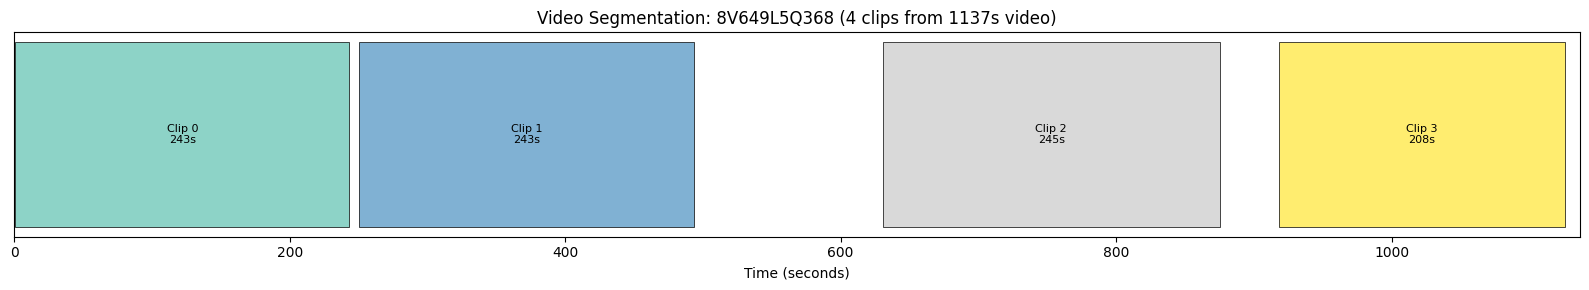

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 3))

colors = plt.cm.Set3(np.linspace(0, 1, max(len(clips), 1)))

for i, clip in enumerate(clips):
    ax.barh(0, clip['duration'], left=clip['start'], height=0.6, 
            color=colors[i], edgecolor='black', linewidth=0.5)
    # Label
    mid = clip['start'] + clip['duration'] / 2
    ax.text(mid, 0, f"Clip {i}\n{clip['duration']:.0f}s", 
            ha='center', va='center', fontsize=8)

ax.set_xlim(0, asr_data['duration_sec'])
ax.set_xlabel('Time (seconds)')
ax.set_yticks([])
ax.set_title(f"Video Segmentation: {asr_data['video_id']} ({len(clips)} clips from {asr_data['duration_sec']:.0f}s video)")
plt.tight_layout()
plt.show()

## 4. Inspect Individual Clips

In [6]:
# Show detailed content of each clip
for i, clip in enumerate(clips):
    print(f"\n{'='*70}")
    print(f"CLIP {i} | {clip['start']:.1f}s - {clip['end']:.1f}s | Duration: {clip['duration']:.1f}s")
    print(f"{'='*70}")
    print(f"\nText ({len(clip['text'])} chars):")
    # Word wrap at 80 chars
    words = clip['text'].split()
    line = ''
    for w in words:
        if len(line) + len(w) > 80:
            print(f"  {line}")
            line = w
        else:
            line = f"{line} {w}" if line else w
    if line:
        print(f"  {line}")
    print()


CLIP 0 | 0.7s - 243.3s | Duration: 242.6s

Text (4375 chars):
  Hi, I'm Dr. John Kugler with the Stanford 25 Ultra Sound series. Today, we're
  going to be learning about lung ultrasound. Now, lung ultrasound is really
  important, especially in my practice as a hospitalist. I use lung ultrasound all
  the time to evaluate patients for various conditions. Today, I want to focus on
  pneumothorax, pleural effusions, as well as telling the difference between a
  lines and b lines, which will help us to better understand if a patient might
  have a pulmonary edema or an pneumonia. To get started, we'll start with
  pneumothorax. Now, as a hospitalist, I don't diagnose a lot of pneumothoracies,
  right? My colleagues down on the ED are usually checking this out more than I am,
  but it can be useful, especially after performing a procedure where pneumothorax
  is possible. Now, using a ultrasound to look for pneumothorax is really nice
  because it's quick and it has a very, very high neg

## 5. Visual segmentation

In [7]:
import cv2
import numpy as np

In [ ]:
def compute_segment_visual_changes(video_path,segments,threshold=0.5):
    """
    对每个ASR segment取一帧，计算与前一帧的直方图相似度。
    返回每个segment的视觉变化情况。
    """
    cap=cv2.VideoCapture(str(video_path))
    prev_hist=None
    results=[]
    for i, seg in enumerate(segments):
        mid_time=(seg['start']+seg['end'])/2
        cap.set(cv2.CAP_PROP_POS_MSEC, mid_time * 1000)
        ret, frame = cap.read()
        if not ret:
            results.append({'seg_idx': i, 'similarity': None, 'scene_change': False})
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        
        if prev_hist is not None:
            similarity = cv2.compareHist(prev_hist, hist, cv2.HISTCMP_CORREL)
            scene_change = similarity < threshold
        else:
            similarity = 1.0
            scene_change = False
        
        results.append({
            'seg_idx': i,
            'start': seg['start'],
            'end': seg['end'],
            'text': seg['text'][:50],
            'similarity': round(similarity, 3),
            'scene_change': scene_change
        })
        
        prev_hist = hist
    
    cap.release()
    return results

In [13]:
VIDEO_PATH = 'UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4'
visual_changes = compute_segment_visual_changes(VIDEO_PATH, segments, threshold=0.3)

In [14]:
print(f"Total segments: {len(visual_changes)}")
print(f"Scene changes detected: {sum(1 for v in visual_changes if v['scene_change'])}")
print()

for v in visual_changes:
    marker = "⚡CHANGE" if v['scene_change'] else "       "
    sim = f"{v['similarity']:.3f}" if v['similarity'] else "N/A  "
    print(f"  Seg {v['seg_idx']:3d} [{v['start']:6.1f}-{v['end']:6.1f}s] sim={sim} {marker} {v['text']}")

Total segments: 223
Scene changes detected: 15

  Seg   0 [   0.7-   4.5s] sim=1.000         Hi, I'm Dr. John Kugler with the Stanford 25 Ultra
  Seg   1 [   4.5-   7.1s] sim=0.997         Today, we're going to be learning about lung ultra
  Seg   2 [   7.1-  12.0s] sim=0.468         Now, lung ultrasound is really important, especial
  Seg   3 [  12.0-  16.0s] sim=0.994         I use lung ultrasound all the time to evaluate pat
  Seg   4 [  16.2-  22.3s] sim=0.998         Today, I want to focus on pneumothorax, pleural ef
  Seg   5 [  22.3-  25.3s] sim=0.998         difference between a lines and b lines, which will
  Seg   6 [  25.3-  28.0s] sim=0.997         if a patient might have a pulmonary edema or an pn
  Seg   7 [  28.0-  32.1s] sim=0.995         To get started, we'll start with pneumothorax.
  Seg   8 [  32.4-  36.0s] sim=0.994         Now, as a hospitalist, I don't diagnose a lot of p
  Seg   9 [  36.0-  40.1s] sim=0.998         My colleagues down on the ED are usually checki

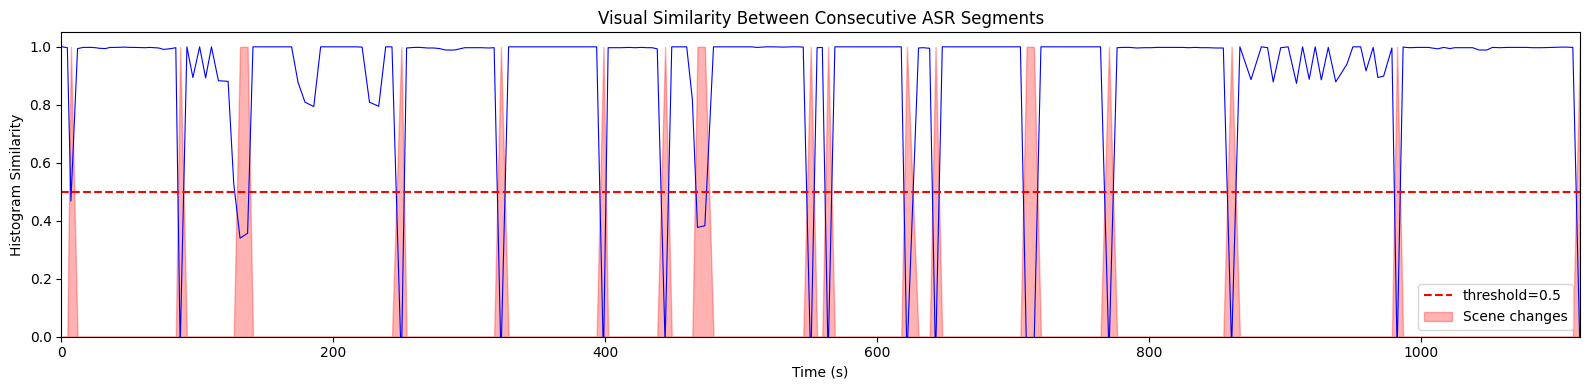

In [12]:
import matplotlib.pyplot as plt

times = [v['start'] for v in visual_changes if v['similarity'] is not None]
sims = [v['similarity'] for v in visual_changes if v['similarity'] is not None]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(times, sims, 'b-', linewidth=0.8)
ax.axhline(y=0.5, color='r', linestyle='--', label='threshold=0.5')
ax.fill_between(times, 0, [1 if s < 0.5 else 0 for s in sims], alpha=0.3, color='red', label='Scene changes')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Histogram Similarity')
ax.set_title('Visual Similarity Between Consecutive ASR Segments')
ax.legend()
ax.set_xlim(0, max(times))
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [16]:
def segment_enhanced(segments, visual_changes, min_clip=30, max_clip=300, tolerance=10):
    """
    Enhanced segmentation: use visual scene changes as priority cut points.
    Falls back to max_clip forced cut at nearest sentence boundary.
    
    Logic:
    1. Collect all scene_change timestamps
    2. For each scene_change, find nearest sentence-ending segment BEFORE it (within tolerance)
    3. Build clips between these cut points
    4. If a clip exceeds max_clip without a scene_change, force cut at nearest sentence end
    """
    # Get scene change times
    scene_change_times = [v['start'] for v in visual_changes if v['scene_change']]
    
    # Find all sentence-ending segment indices
    sentence_end_indices = []
    for i, s in enumerate(segments):
        if s['text'].rstrip().endswith(('.', '?', '!')):
            sentence_end_indices.append(i)
    
    # For each scene change, find the best cut point (sentence end before or at scene change)
    cut_indices = set()
    for sc_time in scene_change_times:
        # Find sentence ends within [sc_time - tolerance, sc_time + tolerance]
        best_idx = None
        best_dist = float('inf')
        for idx in sentence_end_indices:
            seg_end = segments[idx]['end']
            dist = abs(seg_end - sc_time)
            if dist <= tolerance and dist < best_dist:
                best_idx = idx
                best_dist = dist
        if best_idx is not None:
            cut_indices.add(best_idx)
    
    # Sort cut indices
    cut_indices = sorted(cut_indices)
    
    # Build clips from cut indices
    clips = []
    clip_start_idx = 0
    
    for cut_idx in cut_indices:
        # Check minimum clip length
        clip_start_time = segments[clip_start_idx]['start']
        clip_end_time = segments[cut_idx]['end']
        duration = clip_end_time - clip_start_time
        
        if duration >= min_clip:
            clip_segs = segments[clip_start_idx:cut_idx+1]
            clips.append({
                'clip_idx': len(clips),
                'start': clip_start_time,
                'end': clip_end_time,
                'duration': round(duration, 2),
                'num_segments': len(clip_segs),
                'text': ' '.join(s['text'] for s in clip_segs),
                'cut_reason': 'scene_change'
            })
            clip_start_idx = cut_idx + 1
    
    # Handle remaining segments after last cut
    if clip_start_idx < len(segments):
        clip_start_time = segments[clip_start_idx]['start']
        clip_end_time = segments[-1]['end']
        duration = clip_end_time - clip_start_time
        if duration >= min_clip:
            clip_segs = segments[clip_start_idx:]
            clips.append({
                'clip_idx': len(clips),
                'start': clip_start_time,
                'end': clip_end_time,
                'duration': round(duration, 2),
                'num_segments': len(clip_segs),
                'text': ' '.join(s['text'] for s in clip_segs),
                'cut_reason': 'end_of_video'
            })
    
    # Post-process: split clips that are too long (> max_clip)
    final_clips = []
    for clip in clips:
        if clip['duration'] <= max_clip:
            clip['clip_idx'] = len(final_clips)
            final_clips.append(clip)
        else:
            # Force split at sentence boundaries within this clip
            # Find segments in this clip range
            clip_segs = [s for s in segments if s['start'] >= clip['start'] and s['end'] <= clip['end']]
            sub_start = 0
            for si, s in enumerate(clip_segs):
                sub_dur = clip_segs[si]['end'] - clip_segs[sub_start]['start']
                if sub_dur >= max_clip:
                    # Find nearest sentence end before this point
                    for back in range(si-1, sub_start, -1):
                        if clip_segs[back]['text'].rstrip().endswith(('.', '?', '!')):
                            sub_end_time = clip_segs[back]['end']
                            sub_text = ' '.join(cs['text'] for cs in clip_segs[sub_start:back+1])
                            final_clips.append({
                                'clip_idx': len(final_clips),
                                'start': clip_segs[sub_start]['start'],
                                'end': sub_end_time,
                                'duration': round(sub_end_time - clip_segs[sub_start]['start'], 2),
                                'num_segments': back - sub_start + 1,
                                'text': sub_text,
                                'cut_reason': 'max_clip_sentence_boundary'
                            })
                            sub_start = back + 1
                            break
            # Remaining
            if sub_start < len(clip_segs):
                sub_text = ' '.join(cs['text'] for cs in clip_segs[sub_start:])
                sub_dur = clip_segs[-1]['end'] - clip_segs[sub_start]['start']
                if sub_dur >= min_clip:
                    final_clips.append({
                        'clip_idx': len(final_clips),
                        'start': clip_segs[sub_start]['start'],
                        'end': clip_segs[-1]['end'],
                        'duration': round(sub_dur, 2),
                        'num_segments': len(clip_segs) - sub_start,
                        'text': sub_text,
                        'cut_reason': 'max_clip_remainder'
                    })
    
    return final_clips

In [17]:
enhanced_clips = segment_enhanced(segments, visual_changes, min_clip=30, max_clip=300, tolerance=10)

print(f"Enhanced Segmentation: {len(enhanced_clips)} clips")
print(f"Coverage: {sum(c['duration'] for c in enhanced_clips)/asr_data['duration_sec']*100:.0f}%")
print()
for c in enhanced_clips:
    last_sentence = c['text'].rstrip().split('.')[-2] + '.' if '.' in c['text'] else c['text'][-50:]
    print(f"  Clip {c['clip_idx']:2d} | {c['start']:6.1f}-{c['end']:6.1f}s | {c['duration']:5.0f}s | {c['cut_reason']:30s}")
    print(f"         Ends with: ...{last_sentence[-60:]}")
    print()


Enhanced Segmentation: 7 clips
Coverage: 99%

  Clip  0 |    0.7-  87.5s |    87s | scene_change                  
         Ends with: ...could do this scan with many different probes, and it works.

  Clip  1 |   87.5- 250.2s |   163s | scene_change                  
         Ends with: ...should be nervous that this patient may have a pneumothorax.

  Clip  2 |  250.2- 434.6s |   184s | scene_change                  
         Ends with: ... So first, let's position our patient.

  Clip  3 |  434.6- 630.6s |   196s | scene_change                  
         Ends with: ... now, we've really just looked at the area around the lungs.

  Clip  4 |  630.6- 776.7s |   146s | scene_change                  
         Ends with: ...do lung ultrasound, there is not one defined way to do this.

  Clip  5 |  776.7- 978.8s |   202s | scene_change                  
         Ends with: ... I've got a lines.

  Clip  6 |  978.8-1126.3s |   147s | scene_change                  
         Ends with: ... q

In [18]:
for c in enhanced_clips:
    print(f"\n{'='*80}")
    print(f"CLIP {c['clip_idx']} | {c['start']:.1f}s - {c['end']:.1f}s | Duration: {c['duration']:.1f}s | Cut: {c['cut_reason']}")
    print(f"{'='*80}")
    print()
    # Word wrap
    words = c['text'].split()
    line = ''
    for w in words:
        if len(line) + len(w) > 90:
            print(f"  {line}")
            line = w
        else:
            line = f"{line} {w}" if line else w
    if line:
        print(f"  {line}")
    print()



CLIP 0 | 0.7s - 87.5s | Duration: 86.8s | Cut: scene_change

  Hi, I'm Dr. John Kugler with the Stanford 25 Ultra Sound series. Today, we're going to be
  learning about lung ultrasound. Now, lung ultrasound is really important, especially in my
  practice as a hospitalist. I use lung ultrasound all the time to evaluate patients for
  various conditions. Today, I want to focus on pneumothorax, pleural effusions, as well as
  telling the difference between a lines and b lines, which will help us to better understand
  if a patient might have a pulmonary edema or an pneumonia. To get started, we'll start with
  pneumothorax. Now, as a hospitalist, I don't diagnose a lot of pneumothoracies, right? My
  colleagues down on the ED are usually checking this out more than I am, but it can be
  useful, especially after performing a procedure where pneumothorax is possible. Now, using
  a ultrasound to look for pneumothorax is really nice because it's quick and it has a very,
  very high negati